# Clasificación con Regresión Logística

En los labs 02 al 05 predecíamos un número continuo (el precio de una casa) con regresión lineal y polinomial. A partir de aquí el objetivo cambia: predecir una **categoría**. Esta primera sección explica qué es la clasificación y por qué las funciones que ya conocemos (lineales y polinomiales) no sirven para este problema.

### ¿Qué es la Clasificación?

Es el segundo gran tipo de aprendizaje supervisado: en vez de predecir un número continuo $\hat{y} \in \mathbb{R}$ (regresión), el modelo predice a cuál **categoría** o **clase** pertenece cada ejemplo.

- Clasificación binaria: solo hay dos clases, por convención $y = 0$ (clase negativa) y $y = 1$ (clase positiva). Ejemplos: correo spam ($1$) o no spam ($0$), tumor maligno ($1$) o benigno ($0$), transacción fraude ($1$) o legítima ($0$).
- La salida que buscamos ya no es una cantidad, sino una **decisión**: ¿a qué lado de la frontera cae $x^{(i)}$?

(Existe también la clasificación multiclase —el dígito del 0 al 9 en una imagen, por ejemplo—, pero este lab se concentra en el caso binario, que es la base de la Regresión Logística.)

### ¿Por qué ya no sirve la Regresión Lineal?

La idea ingenua sería reutilizar lo que ya sabemos: entrenar la recta $f_{w,b}(x^{(i)}) = w x^{(i)} + b$ sobre etiquetas $0$ y $1$, y fijar un **umbral de decisión** en $0.5$:

$$\hat{y}^{(i)} = 1 \text{ si } f_{w,b}(x^{(i)}) \ge 0.5, \quad \hat{y}^{(i)} = 0 \text{ en caso contrario}$$

Suena razonable, pero tiene tres fallos graves:

1. **Un solo outlier mueve la frontera.** La recta se ajusta por mínimos cuadrados, así que un ejemplo atípico lejano (un tumor enorme aunque sea benigno) tuerce toda la recta y corre el umbral, como verás en el laboratorio de abajo.
2. **La salida no está acotada.** La recta devuelve cualquier número real: $f_{w,b}(x) = 2.5$ o $f_{w,b}(x) = -0.8$ no significan nada como probabilidad, y no hay forma de interpretarlas como $P(y = 1 \mid x)$.
3. **El costo MSE minimiza distancias, no separa clases.** La función $J(w,b)$ del Lab 02 penaliza qué tan lejos cae la recta de cada punto, pero clasificar bien es una pregunta de *lado* (¿arriba o abajo del umbral?), no de distancia. Estaríamos optimizando lo incorrecto.

### Laboratorio de Ejemplo: el umbral que se mueve (tumor benigno vs. maligno)

Objetivo

Ajustar una recta sobre datos de tumores (tamaño $x$ → $y = 0$ benigno, $y = 1$ maligno) y comprobar que un solo outlier benigno rompe el umbral de decisión.

Paso 1: Definir el dataset

Creamos un dataset base con $m = 8$ tumores y le agregamos un outlier: un tumor enorme ($x = 15$) pero benigno ($y = 0$). Ajustamos $f_{w,b}$ por mínimos cuadrados en ambos casos y marcamos dónde queda el umbral $f_{w,b}(x) = 0.5$.

Dataset base: m = 8 | Con outlier: m = 9
Umbral sin outlier: x = 4.50 | Umbral con outlier: x = 8.00
Tumores malignos clasificados como benignos con el outlier: 3 de 4


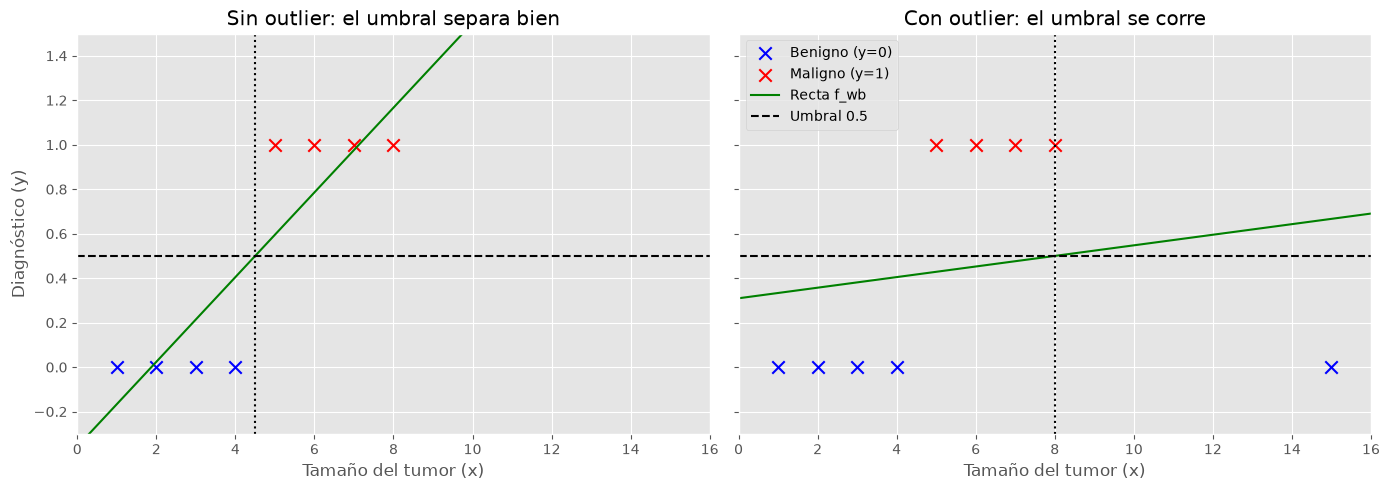

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para las gráficas
plt.style.use('ggplot')

# Dataset base: tamaño del tumor (x) y diagnóstico (y: 0 = benigno, 1 = maligno)
x_base = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
y_base = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Outlier: un tumor enorme (x = 15) pero benigno (y = 0)
x_out, y_out = 15.0, 0
x_full = np.append(x_base, x_out)
y_full = np.append(y_base, y_out)

print(f"Dataset base: m = {x_base.shape[0]} | Con outlier: m = {x_full.shape[0]}")

def fit_line(x, y):
    """
    Ajusta f_wb(x) = w*x + b por mínimos cuadrados.
    Args:
      x (ndarray (m,)): tamaños de tumor
      y (ndarray (m,)): diagnósticos (0 o 1)
    Returns:
      w, b (scalar): parámetros de la recta
    """
    A = np.column_stack([x, np.ones_like(x)])
    w, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return w, b

w1, b1 = fit_line(x_base, y_base)
w2, b2 = fit_line(x_full, y_full)

# Umbral de decisión: el punto x donde la recta cruza f_wb(x) = 0.5
thr1 = (0.5 - b1) / w1
thr2 = (0.5 - b2) / w2
print(f"Umbral sin outlier: x = {thr1:.2f} | Umbral con outlier: x = {thr2:.2f}")

# ¿Cuántos tumores malignos quedan del lado equivocado por culpa del outlier?
mal_clasificados = np.sum(x_base[y_base == 1] < thr2 - 1e-9)  # tolerancia: x=8 cae justo sobre el umbral
print(f"Tumores malignos clasificados como benignos con el outlier: {mal_clasificados} de 4")

# Gráfica comparativa: sin outlier vs. con outlier
xs = np.linspace(0, 16, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, x_d, y_d, w, b, thr, title in [
    (ax1, x_base, y_base, w1, b1, thr1, "Sin outlier: el umbral separa bien"),
    (ax2, x_full, y_full, w2, b2, thr2, "Con outlier: el umbral se corre"),
]:
    ax.scatter(x_d[y_d == 0], y_d[y_d == 0], marker='x', c='b', s=80, label='Benigno (y=0)')
    ax.scatter(x_d[y_d == 1], y_d[y_d == 1], marker='x', c='r', s=80, label='Maligno (y=1)')
    ax.plot(xs, w * xs + b, c='g', label='Recta f_wb')
    ax.axhline(0.5, c='k', linestyle='--', label='Umbral 0.5')
    ax.axvline(thr, c='k', linestyle=':')
    ax.set_title(title)
    ax.set_xlabel("Tamaño del tumor (x)")
    ax.set_xlim(0, 16)
    ax.set_ylim(-0.3, 1.5)

ax1.set_ylabel("Diagnóstico (y)")
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

### ¿Y la Regresión Polinomial del Lab 5?

En el Lab 5 los polinomios resolvieron la *curvatura* de una salida continua (el precio seguía siendo un número). Pero el problema de clasificación no es de curvatura, es de **naturaleza de la salida**: por más grados que agregues ($x^2, x^3, \dots$), la curva sigue devolviendo cualquier número real.

Eso produce dos síntomas visibles en la gráfica de abajo:

- **Predicciones fuera de $[0,1]$**: la cúbica llega a valores negativos y mayores que $1$, que no pueden leerse como probabilidad.
- **El umbral se cruza varias veces**: la curva corta la línea $0.5$ en dos puntos, así que la 'región maligna' queda fragmentada en intervalos. Con más grados aparecen más cruces, no menos.

Más flexibilidad no arregla un modelo cuya salida no está acotada.

Coeficientes del polinomio (grado 3): [-0.003   0.0464 -0.0152 -0.1285]
Predicción mínima: -0.74 (fuera de [0,1] por abajo)
Predicción máxima: 1.37 (fuera de [0,1] por arriba)
La curva cruza el umbral 0.5 en x = [4.65, 14.12]


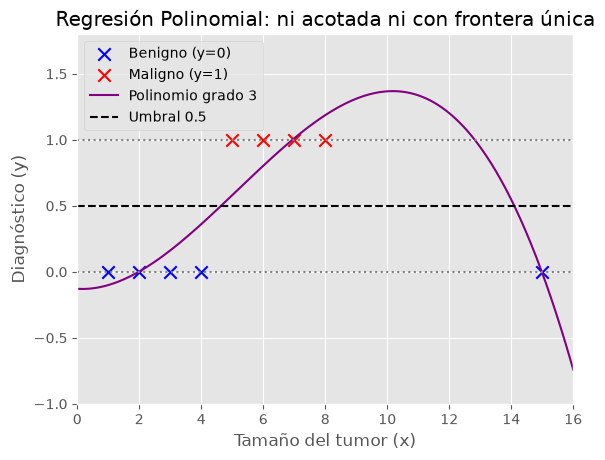

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para las gráficas
plt.style.use('ggplot')

# Mismo dataset con el outlier del paso anterior
x_full = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 15.0])
y_full = np.array([0, 0, 0, 0, 1, 1, 1, 1, 0])

# Ajuste cúbico (Regresión Polinomial de grado 3)
coef = np.polyfit(x_full, y_full, 3)
print(f"Coeficientes del polinomio (grado 3): {np.round(coef, 4)}")

xs = np.linspace(0, 16, 400)
ys = np.polyval(coef, xs)
print(f"Predicción mínima: {ys.min():.2f} (fuera de [0,1] por abajo)")
print(f"Predicción máxima: {ys.max():.2f} (fuera de [0,1] por arriba)")

# Puntos donde la curva cruza el umbral 0.5 (frontera fragmentada)
cruces = [round(float(xs[i]), 2) for i in range(1, len(xs)) if (ys[i-1] - 0.5) * (ys[i] - 0.5) < 0]
print(f"La curva cruza el umbral 0.5 en x = {cruces}")

# Gráfica del ajuste cúbico contra los datos reales
plt.scatter(x_full[y_full == 0], y_full[y_full == 0], marker='x', c='b', s=80, label='Benigno (y=0)')
plt.scatter(x_full[y_full == 1], y_full[y_full == 1], marker='x', c='r', s=80, label='Maligno (y=1)')
plt.plot(xs, ys, c='purple', label='Polinomio grado 3')
plt.axhline(0.5, c='k', linestyle='--', label='Umbral 0.5')
plt.axhline(0, c='gray', linestyle=':')
plt.axhline(1, c='gray', linestyle=':')
plt.title("Regresión Polinomial: ni acotada ni con frontera única")
plt.xlabel("Tamaño del tumor (x)")
plt.ylabel("Diagnóstico (y)")
plt.xlim(0, 16)
plt.ylim(-1.0, 1.8)
plt.legend()
plt.show()

### Lo que necesitamos

Para clasificar bien necesitamos una función con dos propiedades que ni la recta ni los polinomios tienen:

1. **Salida acotada a $[0, 1]$**, interpretable como probabilidad: $P(y = 1 \mid x)$.
2. **Frontera de decisión estable**, que no se mueva de forma drástica por un solo ejemplo atípico.

Esa función existe: la **función sigmoide** (o logística)

$$g(z) = \frac{1}{1 + e^{-z}}$$

que aplasta cualquier número real $z$ al intervalo $(0, 1)$. En la siguiente sección la combinaremos con el modelo lineal ($z = w x + b$) para construir la **Regresión Logística**.

### La función sigmoide

En la sección anterior vimos que para clasificar necesitamos una salida acotada a $[0, 1]$, interpretable como probabilidad. Esa función existe: la **función sigmoide** (o logística)

$$g(z) = \frac{1}{1 + e^{-z}}$$

Lo que hace es **aplastar** cualquier número real $z$ (desde $-\infty$ hasta $+\infty$) al intervalo $(0, 1)$:

- Si $z$ es muy negativo, $e^{-z}$ es enorme y $g(z) \approx 0$.
- Si $z$ es muy positivo, $e^{-z} \approx 0$ y $g(z) \approx 1$.
- En el punto medio, $g(0) = \frac{1}{1 + 1} = 0.5$.

Por eso su gráfica tiene forma de **S**: se pega al $0$ a la izquierda, cruza $0.5$ en el origen y se pega al $1$ a la derecha. Y de ahí viene el nombre del algoritmo: la Regresión Logística no predice la clase directamente, sino una **probabilidad usando esta función logística**.

### ¿Qué es $z$?

$z$ es simplemente un número real cualquiera: un **puntaje** que mide qué tan fuerte es la evidencia a favor de la clase positiva ($y = 1$).

- El **signo** de $z$ decide el lado: si $z > 0$, entonces $g(z) > 0.5$ (más probable la clase $1$); si $z < 0$, entonces $g(z) < 0.5$ (más probable la clase $0$). El punto $z = 0$ es el empate exacto ($g = 0.5$) y ahí queda la **frontera de decisión**.
- La **magnitud** $|z|$ mide la confianza: un $|z|$ grande aplasta $g(z)$ contra $0$ o contra $1$ (el modelo está seguro); un $|z|$ chico deja $g(z)$ cerca de $0.5$ (el modelo duda).

¿Y de dónde sale $z$ en nuestro modelo? De la misma recta de siempre: $z = w x + b$. La diferencia es que ya no usamos su valor como predicción, sino como puntaje que entra a la sigmoide: $f_{w,b}(x) = g(w x + b)$.

g(-5) = 0.0067 | g(0) = 0.5000 | g(5) = 0.9933


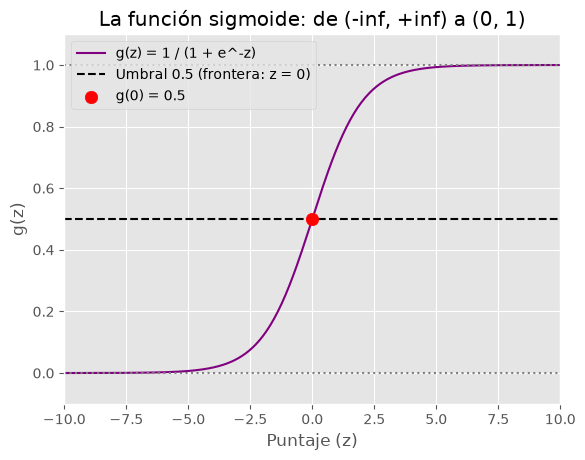

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para las gráficas
plt.style.use('ggplot')

def sigmoid(z):
    """
    Calcula la función sigmoide g(z) = 1 / (1 + e^(-z)).
    Args:
      z (scalar o ndarray): puntaje (cualquier número real)
    Returns:
      g (scalar o ndarray): valor aplastado al intervalo (0, 1)
    """
    return 1 / (1 + np.exp(-z))

# Valores clave: extremos y punto medio
print(f"g(-5) = {sigmoid(-5):.4f} | g(0) = {sigmoid(0):.4f} | g(5) = {sigmoid(5):.4f}")

# Paso 2: Graficar la curva S de la sigmoide
z = np.linspace(-10, 10, 400)
g = sigmoid(z)

plt.plot(z, g, c='purple', label='g(z) = 1 / (1 + e^-z)')
plt.axhline(0.5, c='k', linestyle='--', label='Umbral 0.5 (frontera: z = 0)')
plt.axhline(0, c='gray', linestyle=':')
plt.axhline(1, c='gray', linestyle=':')
plt.scatter([0], [0.5], c='r', s=80, zorder=5, label='g(0) = 0.5')
plt.title("La función sigmoide: de (-inf, +inf) a (0, 1)")
plt.xlabel("Puntaje (z)")
plt.ylabel("g(z)")
plt.xlim(-10, 10)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

### Puente al modelo: del puntaje a la probabilidad (tumores)

Cerremos el círculo con el dataset de tumores del laboratorio anterior ($x$ = tamaño, $y = 0$ benigno, $y = 1$ maligno). Tomamos un puntaje lineal de ejemplo, $z = w x + b$ con $w = 1.0$ y $b = -4.5$ (su frontera $z = 0$ queda en $x = 4.5$, igual que el umbral lineal sin outlier):

- Tumor chico ($x = 3$): $z = 1.0 \cdot 3 - 4.5 = -1.5$ → $g(-1.5) \approx 0.18$. Solo 18% de probabilidad de ser maligno → se clasifica benigno ($\hat{y} = 0$).
- Tumor grande ($x = 7$): $z = 1.0 \cdot 7 - 4.5 = +2.5$ → $g(2.5) \approx 0.92$. Un 92% de probabilidad → se clasifica maligno ($\hat{y} = 1$).

La regla de decisión queda así:

$$\hat{y}^{(i)} = 1 \text{ si } g(z^{(i)}) \ge 0.5 \iff z^{(i)} \ge 0, \quad \hat{y}^{(i)} = 0 \text{ en caso contrario}$$

Es decir, el modelo completo de Regresión Logística es $f_{w,b}(x) = g(w x + b)$: la recta aporta el puntaje y la sigmoide lo convierte en probabilidad. En la gráfica de abajo verás esa curva en forma de S montada sobre los puntos del tumor, con la frontera justo donde $z = 0$.

x = 3.0: z = -1.5 --> g(z) = 0.18
x = 7.0: z = +2.5 --> g(z) = 0.92


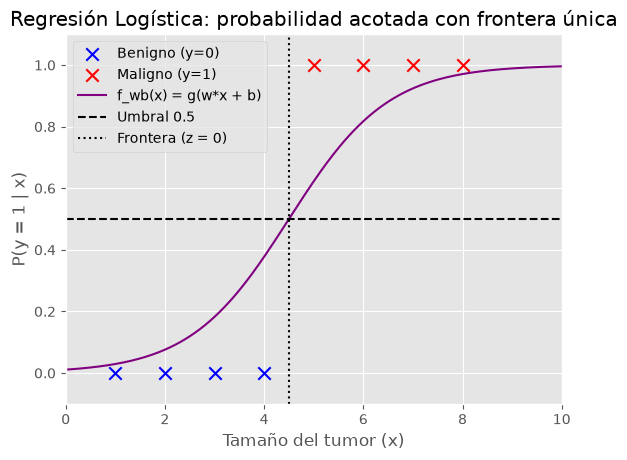

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para las gráficas
plt.style.use('ggplot')

def sigmoid(z):
    """Calcula la función sigmoide g(z) = 1 / (1 + e^(-z))."""
    return 1 / (1 + np.exp(-z))

# Dataset base de tumores (m = 8) del laboratorio anterior
x_tumor = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
y_tumor = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Parámetros de ejemplo: la frontera z = 0 queda en x = 4.5
w_log, b_log = 1.0, -4.5

# Paso 3: Del puntaje z a la probabilidad g(z) en dos casos
for x_ej in [3.0, 7.0]:
    z_ej = w_log * x_ej + b_log
    print(f"x = {x_ej}: z = {z_ej:+.1f} --> g(z) = {sigmoid(z_ej):.2f}")

# Curva del modelo f_wb(x) = g(w*x + b) sobre los datos reales
xs = np.linspace(0, 10, 400)
probs = sigmoid(w_log * xs + b_log)

plt.scatter(x_tumor[y_tumor == 0], y_tumor[y_tumor == 0], marker='x', c='b', s=80, label='Benigno (y=0)')
plt.scatter(x_tumor[y_tumor == 1], y_tumor[y_tumor == 1], marker='x', c='r', s=80, label='Maligno (y=1)')
plt.plot(xs, probs, c='purple', label='f_wb(x) = g(w*x + b)')
plt.axhline(0.5, c='k', linestyle='--', label='Umbral 0.5')
plt.axvline(4.5, c='k', linestyle=':', label='Frontera (z = 0)')
plt.title("Regresión Logística: probabilidad acotada con frontera única")
plt.xlabel("Tamaño del tumor (x)")
plt.ylabel("P(y = 1 | x)")
plt.xlim(0, 10)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.show()

### Decision boundaries: de un punto a una curva

En el puente anterior la frontera fue un **punto** ($x = 4.5$). Eso solo pasa porque usábamos una sola feature. La definición general de **frontera de decisión** (decision boundary) es el conjunto de entradas donde el puntaje vale cero:

$$\text{frontera} = \{x : z(x) = 0\} \iff \{x : g(z) = 0.5\}$$

Y aquí está la clave: la **forma** de la frontera la decide qué metes dentro de $z(x)$, no la sigmoide:

- 1 feature ($z = w x + b$): $z = 0$ es un **punto** ($x = -b / w$). Lo ya visto.
- 2 features ($z = w_1 x_1 + w_2 x_2 + b$): $z = 0$ es una **recta** que parte el plano en dos.
- $n$ features: $z = 0$ es un **hiperplano** (un plano en 3D, y así sucesivamente).
- Si $z$ lleva potencias ($x_1^2, x_2^2, \dots$): la frontera se vuelve **curva** (círculos, elipses).

Veamos los casos 2D con dos laboratorios: una recta y un círculo.

### Laboratorio: frontera lineal en 2D (tumores con dos features)

Objetivo

Separar tumores usando dos features ($x_1$ = tamaño en cm, $x_2$ = densidad en escala 0–10) con una frontera recta.

Paso 4: Dataset y puntaje lineal

Tomamos $z = x_1 + x_2 - 10$ (o sea, $w_1 = 1.0$, $w_2 = 1.0$, $b = -10.0$). La frontera $z = 0$ despejada es la recta $x_2 = 10 - x_1$: los puntos debajo de ella suman menos de $10$ (benignos) y los de arriba suman más (malignos).

(x1=3.0, x2=3.0): z = -4.0 --> g(z) = 0.02
(x1=7.0, x2=7.0): z = +4.0 --> g(z) = 0.98


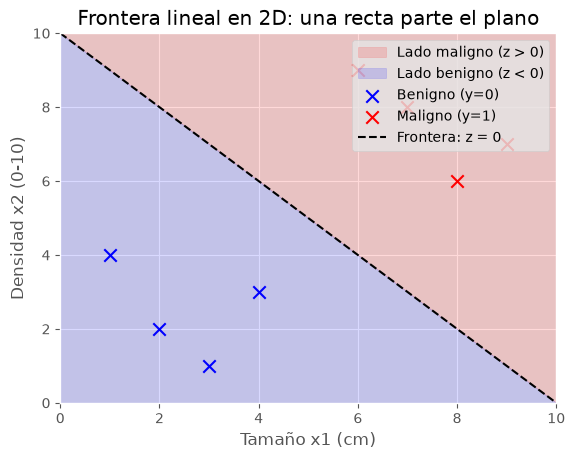

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para las gráficas
plt.style.use('ggplot')

def sigmoid(z):
    """Calcula la función sigmoide g(z) = 1 / (1 + e^(-z))."""
    return 1 / (1 + np.exp(-z))

# Dataset 2D: tumores benignos (suma < 10) y malignos (suma > 10)
x1_ben = np.array([2.0, 3.0, 1.0, 4.0])
x2_ben = np.array([2.0, 1.0, 4.0, 3.0])
x1_mal = np.array([7.0, 8.0, 6.0, 9.0])
x2_mal = np.array([8.0, 6.0, 9.0, 7.0])

# Parámetros del puntaje lineal z = w1*x1 + w2*x2 + b
w1, w2, b = 1.0, 1.0, -10.0

# Paso 5: Del puntaje a la clase en dos casos (uno por lado)
for xa, xb in [(3.0, 3.0), (7.0, 7.0)]:
    z_ej = w1 * xa + w2 * xb + b
    print(f"(x1={xa}, x2={xb}): z = {z_ej:+.1f} --> g(z) = {sigmoid(z_ej):.2f}")

# Frontera: recta x2 = 10 - x1, con lados sombreados
xs = np.linspace(0, 10, 200)
frontera = 10 - xs

plt.fill_between(xs, frontera, 10, color='red', alpha=0.15, label='Lado maligno (z > 0)')
plt.fill_between(xs, 0, frontera, color='blue', alpha=0.15, label='Lado benigno (z < 0)')
plt.scatter(x1_ben, x2_ben, marker='x', c='b', s=80, label='Benigno (y=0)')
plt.scatter(x1_mal, x2_mal, marker='x', c='r', s=80, label='Maligno (y=1)')
plt.plot(xs, frontera, c='k', linestyle='--', label='Frontera: z = 0')
plt.title("Frontera lineal en 2D: una recta parte el plano")
plt.xlabel("Tamaño x1 (cm)")
plt.ylabel("Densidad x2 (0-10)")
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.legend(loc='upper right')
plt.show()

### Frontera no-lineal: el microchip que ninguna recta separa

Piensa en una fábrica de microchips con dos pruebas de calidad ($x_1$, $x_2$). Los chips buenos salen agrupados al centro y los defectuosos forman un **anillo** alrededor. Ninguna recta puede separar un anillo: cualquier línea que traces dejará buenos y malos del mismo lado.

La salida es el truco del Lab 5: meter potencias al puntaje. Con $z = x_1^2 + x_2^2 - 1$, la frontera $z = 0$ es un **círculo de radio 1**: lo de adentro ($z < 0$) se clasifica bueno y lo de afuera ($z > 0$) defectuoso. El modelo sigue siendo lineal en los parámetros ($w$ multiplica a $x_1^2$ como a cualquier columna), pero la frontera en el plano original es curva.

(x1=0.0, x2=0.0): z = -1.00 --> g(z) = 0.27
(x1=1.2, x2=0.0): z = +0.44 --> g(z) = 0.61


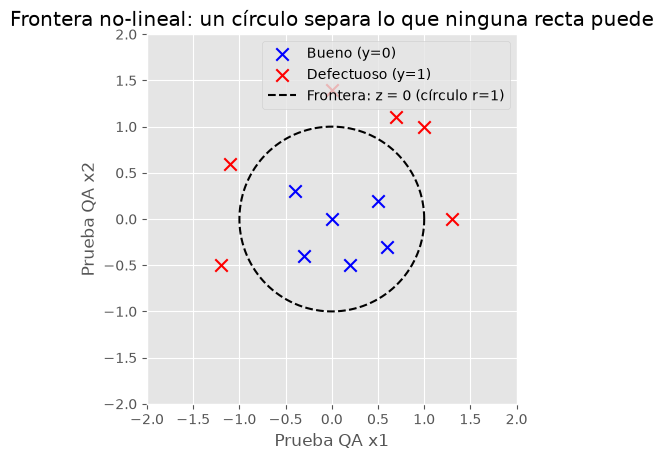

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para las gráficas
plt.style.use('ggplot')

def sigmoid(z):
    """Calcula la función sigmoide g(z) = 1 / (1 + e^(-z))."""
    return 1 / (1 + np.exp(-z))

# Microchips: buenos al centro, defectuosos en anillo alrededor
good = np.array([[0.0, 0.0], [0.5, 0.2], [-0.4, 0.3], [0.2, -0.5], [-0.3, -0.4], [0.6, -0.3]])
bad = np.array([[1.3, 0.0], [0.0, 1.4], [-1.2, -0.5], [1.0, 1.0], [-1.1, 0.6], [0.7, 1.1]])

def z_circle(x1, x2):
    """Puntaje con potencias: z = x1^2 + x2^2 - 1 (frontera circular)."""
    return x1 ** 2 + x2 ** 2 - 1

# Paso 6: Del puntaje a la clase en dos casos (centro vs. afuera)
for xa, xb in [(0.0, 0.0), (1.2, 0.0)]:
    z_ej = z_circle(xa, xb)
    print(f"(x1={xa}, x2={xb}): z = {z_ej:+.2f} --> g(z) = {sigmoid(z_ej):.2f}")

# Frontera: círculo de radio 1 dibujado paramétricamente
theta = np.linspace(0, 2 * np.pi, 400)

plt.scatter(good[:, 0], good[:, 1], marker='x', c='b', s=80, label='Bueno (y=0)')
plt.scatter(bad[:, 0], bad[:, 1], marker='x', c='r', s=80, label='Defectuoso (y=1)')
plt.plot(np.cos(theta), np.sin(theta), c='k', linestyle='--', label='Frontera: z = 0 (círculo r=1)')
plt.title("Frontera no-lineal: un círculo separa lo que ninguna recta puede")
plt.xlabel("Prueba QA x1")
plt.ylabel("Prueba QA x2")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal')
plt.legend(loc='upper right')
plt.show()

### Regla de bolsillo

- **Frontera recta** (punto, recta, hiperplano) $\iff$ puntaje $z$ **lineal** en las features.
- **Frontera curva** (círculos, elipses) $\iff$ puntaje $z$ con **potencias** de las features.

Y recuerda el reparto de roles: la sigmoide solo convierte el puntaje en probabilidad, **nunca define la forma** de la frontera. Con esto el modelo queda completo: $f_{w,b}(x) = g(z(x))$ te dice *qué tan probable* es cada clase y $z(x) = 0$ te dice *dónde* cambia la decisión.